In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
import statsmodels.formula.api as smf

warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# from utils.utils import *
from utils.data_loader import load_data

# Loading data

In [2]:
final_clean_strained = load_data(db_level=0)

In [3]:
peak_curvs = final_clean_strained["PeakI Curvature"].apply(pd.Series)
peak_curvs.columns = [
    "PeakI Left Curvature",
    "PeakI Overall Curvature",
    "PeakI Right Curvature",
]
trough_curvs = final_clean_strained["TroughI Curvature"].apply(pd.Series)
trough_curvs.columns = [
    "TroughI Left Curvature",
    "TroughI Overall Curvature",
    "TroughI Right Curvature",
]
final_clean_strained = pd.concat(
    [final_clean_strained, peak_curvs, trough_curvs], axis=1
)

In [4]:
def split_by_mouse(
    data,
    split_on="Subject",
    stratify_on="Group",
    test_size=0.2,
    val_size=0.2,
    random_state=22,
    return_idx=False,
):
    mice = data[[split_on, stratify_on]].drop_duplicates().set_index(split_on)

    train, test = train_test_split(
        mice.index,
        test_size=test_size,
        shuffle=True,
        stratify=mice[stratify_on],
        random_state=random_state,
    )

    train_indices = data[split_on].isin(train)
    test_indices = data[split_on].isin(test)

    train2, val = train_test_split(
        train,
        test_size=val_size,
        shuffle=True,
        stratify=mice.loc[train]["Group"],
        random_state=random_state,
    )

    train2_indices = data[split_on].isin(train2)
    val_indices = data[split_on].isin(val)

    data["DataGroup"] = ""
    data.loc[train2_indices, "DataGroup"] = "Train"
    data.loc[val_indices, "DataGroup"] = "Validate"
    data.loc[test_indices, "DataGroup"] = "Test"
    if return_idx:
        return data, train_indices, train2_indices, val_indices, test_indices
    return data

# Train test split

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    FunctionTransformer,
    MinMaxScaler,
)


def RF_data_prep(
    data,
    num_features,
    cat_features,
    log_features,
    minmax_features,
    target="SynapsesPerIHC",
):
    X = data[num_features + cat_features + log_features + minmax_features]
    y = data[target]

    X_train, X_test, y_train, y_test = (
        X[data.DataGroup != "Test"],
        X[data.DataGroup == "Test"],
        y[data.DataGroup != "Test"],
        y[data.DataGroup == "Test"],
    )

    log_scale_pipeline = Pipeline(
        [
            ("log_transform", FunctionTransformer(np.log1p, validate=True)),
            ("scaler", StandardScaler()),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_features),
            ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
            ("log_transform", log_scale_pipeline, log_features),
            ("minmax_scale", MinMaxScaler(), minmax_features),
        ]
    )

    return X_train, X_test, y_train, y_test, preprocessor

In [6]:
final_clean_strained = final_clean_strained[final_clean_strained["Noise"] > 0]
final_clean_strained_70 = final_clean_strained[final_clean_strained["Level(dB)"] == 70]
final_clean_strained_70 = split_by_mouse(final_clean_strained_70)
num_features = ["Amplitude", "Slope", "Distance", "Level(dB)"]
cat_features = ["vx", "Strain (binary)"]
log_features = [
    "Frequency(kHz)",
    "Total Variance",
    "PeakI Left Curvature",
    "PeakI Overall Curvature",
    "PeakI Right Curvature",
    "TroughI Left Curvature",
    "TroughI Overall Curvature",
    "TroughI Right Curvature",
]
minmax_features = ["Time (hrs)"]
X_train, X_test, y_train, y_test, preprocessor = RF_data_prep(
    final_clean_strained_70, num_features, cat_features, log_features, minmax_features
)

# Vanilla Linear Regression

In [7]:
smf_df = final_clean_strained_70.copy()
smf_df.columns = [
    "Subject",
    "Frequency",
    "Level",
    "Amplitude",
    "vx",
    "SynapsesPerIHC",
    "IHCs",
    "OrphansPerIHC",
    "Waveform",
    "WaveI",
    "Peaks",
    "Troughs",
    "Slope",
    "TotalVariance",
    "Distance",
    "PeakICurvature",
    "TroughICurvature",
    "Strain",
    "Sex",
    "Group",
    "Noise",
    "Time(str)",
    "Time_hrs",
    "Strain_b",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
    "DataGroup",
]

In [8]:
def VIF(reg: str):
    vif_model = smf.ols(reg, data=smf_df).fit()
    r2j = vif_model.rsquared
    vif_j = 1 / (1 - r2j)
    print(f"VIF for {reg.split("~")[0].strip()}: {vif_j}")


features = [
    "Frequency",
    # "Amplitude",
    "Slope",
    "TotalVariance",
    "Distance",
    "Time_hrs",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]
for feature in features:
    reg = f"{feature} ~ "
    for i in features:
        if i != feature:
            reg += i + " + "
    VIF(reg[:-3])

VIF for Frequency: 1.1766761056487955
VIF for Slope: 7.123557958335471
VIF for TotalVariance: 5.263475045739288
VIF for Distance: 1.1366103056403147
VIF for Time_hrs: 1.036501884037546
VIF for PeakIRightCurvature: 1.6626948899299798
VIF for TroughILeftCurvature: 1.357618847562157
VIF for PeakILeftCurvature: 1.3812350930818627
VIF for PeakIOverallCurvature: 1.1140065334108014
VIF for PeakIRightCurvature: 1.6626948899299798
VIF for TroughIOverallCurvature: 1.1269807598111514
VIF for TroughIRightCurvature: 1.2055078864656261


In [9]:
model_text = "SynapsesPerIHC ~ C(vx) + C(Strain_b)"
for feature in features:
    model_text += f" + {feature}"
model = smf.ols(model_text, data=smf_df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         SynapsesPerIHC   R-squared:                       0.318
Model:                            OLS   Adj. R-squared:                  0.308
Method:                 Least Squares   F-statistic:                     30.59
Date:                Wed, 26 Nov 2025   Prob (F-statistic):           2.69e-62
Time:                        11:25:35   Log-Likelihood:                -2208.2
No. Observations:                 866   AIC:                             4444.
Df Residuals:                     852   BIC:                             4511.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  14.6972      0.588     24.981      0.000      13.542      15.852
C(vx)[T.v2]                 0.0985      0.212      0.464      0.643      -0.318       0.515
C(Strain_b)[T.1]            2.0351      0.303      6.707      0.000       1.440       2.631
Frequency                  -0.0569      0.009     -6.269      0.000      -0.075      -0.039
Slope                      -0.7940      0.203     -3.913      0.000      -1.192      -0.396
TotalVariance              -0.2351      0.069     -3.388      0.001      -0.371      -0.099
Distance                   -1.1227      0.446     -2.518      0.012      -1.998      -0.248
Time_hrs                   -0.0178      0.005     -3.676      0.000      -0.027      -0.008
PeakIRightCurvature        -0.1011      0.014     -7.064      0.000      -0.129      -0.073
TroughILeftCurvature       -0.0355      0.010     -3.589      0.000      -0.055      -0.016
PeakILeftCurvature         -0.0044      0.013     -0.346      0.729      -0.029       0.021
PeakIOverallCurvature      -0.0019      0.005     -0.403      0.687      -0.011       0.007
TroughIOverallCurvature    -0.0037      0.005     -0.763      0.446      -0.013       0.006
TroughIRightCurvature       0.0096      0.009      1.059      0.290      -0.008       0.027
==============================================================================
Omnibus:                       26.613   Durbin-Watson:                   1.120
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               29.826
Skew:                          -0.383   Prob(JB):                     3.34e-07
Kurtosis:                       3.489   Cond. No.                         383.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Elastic Net

In [10]:
pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("elasticnet_cv", ElasticNetCV(alphas=[1e-3, 1e-2, 1e-1, 1, 10], cv=5)),
    ]
)
pipeline.fit(X_train, y_train)
print(f"Elastic Net training set score: {pipeline.score(X_train, y_train)}")
print(f"Elastic Net test set score: {pipeline.score(X_test, y_test)}")

Elastic Net training set score: 0.2582315114948427
Elastic Net test set score: 0.2873490064998041


In [11]:
features = X_train.columns
coefs = pipeline.named_steps["elasticnet_cv"].coef_
count = len(coefs[coefs != 0])
print(f"{count} features were selected")
print(f"Dropped features: {features[coefs == 0].values}")

8 features were selected
Dropped features: ['Amplitude' 'Slope' 'Level(dB)' 'vx' 'Total Variance'
 'PeakI Overall Curvature' 'TroughI Overall Curvature']


# Random Forest

In [12]:
rf_params = {
    "rf__n_estimators": [25, 50, 100, 150, 200, 300, 400, 500],
    "rf__max_depth": [5, 10, 20, 30, 40, None],
    "rf__min_samples_leaf": [2, 5, 10, 15, 20, 30],
    "rf__min_samples_split": [2, 5, 10, 15, 20, 30],
    "rf__max_features": ["sqrt", "log2", 0.3, 0.5],
}

rf_pipeline = Pipeline(
    [("preprocessor", preprocessor), ("rf", RandomForestRegressor(random_state=1))]
)

# Use RandomizedSearchCV for efficiency
rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring="r2",
    random_state=1,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print(f"Best RF params: {rf_search.best_params_}")
r2 = rf_search.score(X_test, y_test)
print(f"Best RF score: {rf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
best_rf_model = rf_search.best_estimator_

Best RF params: {'rf__n_estimators': 500, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 2, 'rf__max_features': 0.3, 'rf__max_depth': 20}
Best RF score: 0.137, R2 on test set: 0.490


# Feature Importance

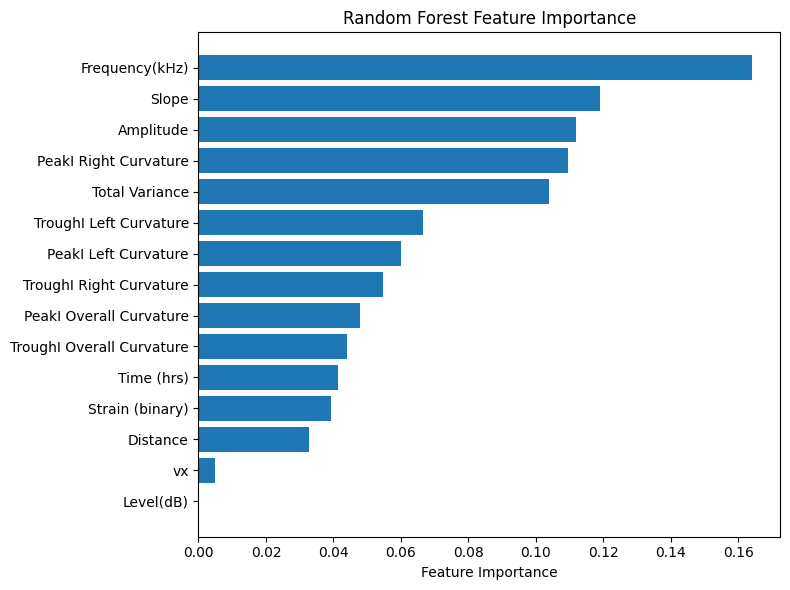

In [13]:
best_rf_model = rf_search.best_estimator_
feature_importance = best_rf_model.named_steps["rf"].feature_importances_
feature_names = best_rf_model.feature_names_in_

importance_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": feature_importance}
).sort_values("Importance", ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(range(len(importance_df)), importance_df["Importance"])
plt.yticks(range(len(importance_df)), importance_df["Feature"])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Permutation Importance


Permutation Importance Rankings:
                      Feature  Importance_Mean  Importance_Std
6              Frequency(kHz)         0.338695        0.059160
10      PeakI Right Curvature         0.121411        0.024322
5             Strain (binary)         0.070289        0.014705
1                       Slope         0.069397        0.016122
7              Total Variance         0.053567        0.012443
14                 Time (hrs)         0.045958        0.016834
0                   Amplitude         0.044188        0.012771
11     TroughI Left Curvature         0.026763        0.010255
13    TroughI Right Curvature         0.018865        0.006149
2                    Distance         0.006418        0.002137
4                          vx         0.000416        0.001064
3                   Level(dB)         0.000000        0.000000
12  TroughI Overall Curvature        -0.004286        0.004179
9     PeakI Overall Curvature        -0.006544        0.005842
8        PeakI Left C

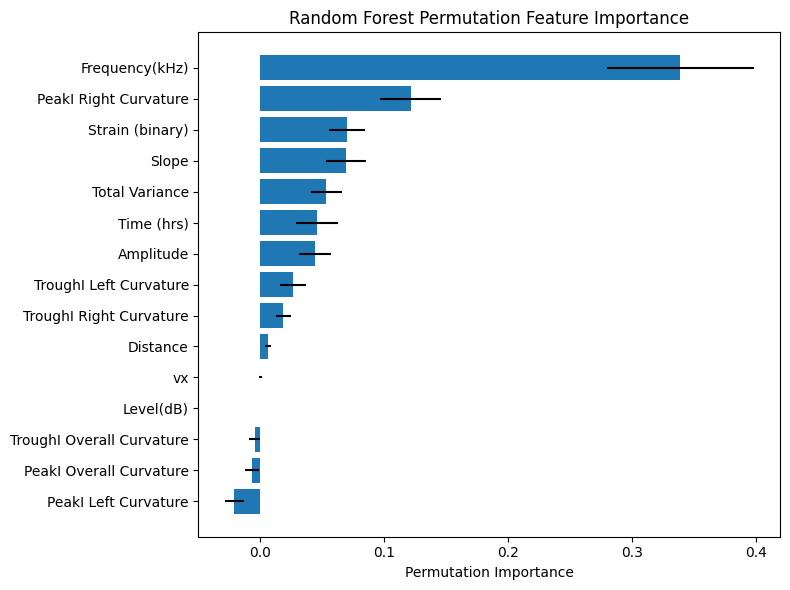

In [14]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    best_rf_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2",
)
perm_importance_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance_Mean": perm_importance.importances_mean,
        "Importance_Std": perm_importance.importances_std,
    }
).sort_values("Importance_Mean", ascending=False)

print("\nPermutation Importance Rankings:")
print(perm_importance_df)

# Plot permutation importance with error bars
plt.figure(figsize=(8, 6))
plt.barh(
    range(len(perm_importance_df)),
    perm_importance_df["Importance_Mean"],
    xerr=perm_importance_df["Importance_Std"],
)
plt.yticks(range(len(perm_importance_df)), perm_importance_df["Feature"])
plt.xlabel("Permutation Importance")
plt.title("Random Forest Permutation Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# SHAP

[Text(0, 0, 'Level(dB)'), Text(0, 1, 'vx'), Text(0, 2, 'Distance'), Text(0, 3, 'TroughI Overall Curvature'), Text(0, 4, 'PeakI Overall Curvature'), Text(0, 5, 'TroughI Right Curvature'), Text(0, 6, 'TroughI Left Curvature'), Text(0, 7, 'PeakI Left Curvature'), Text(0, 8, 'Total Variance'), Text(0, 9, 'Time (hrs)'), Text(0, 10, 'Amplitude'), Text(0, 11, 'Slope'), Text(0, 12, 'PeakI Right Curvature'), Text(0, 13, 'Strain (binary)'), Text(0, 14, 'Frequency(kHz)')]


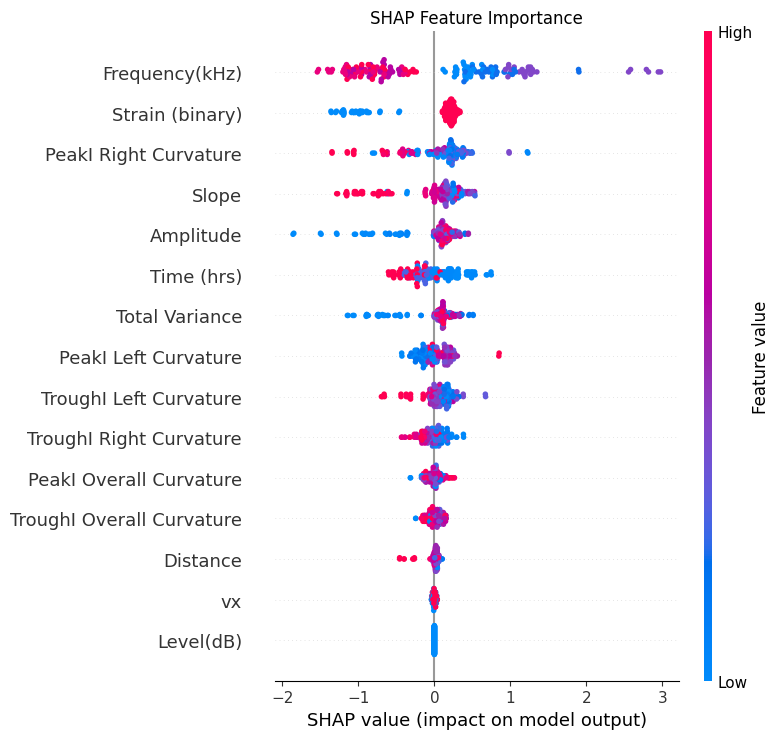

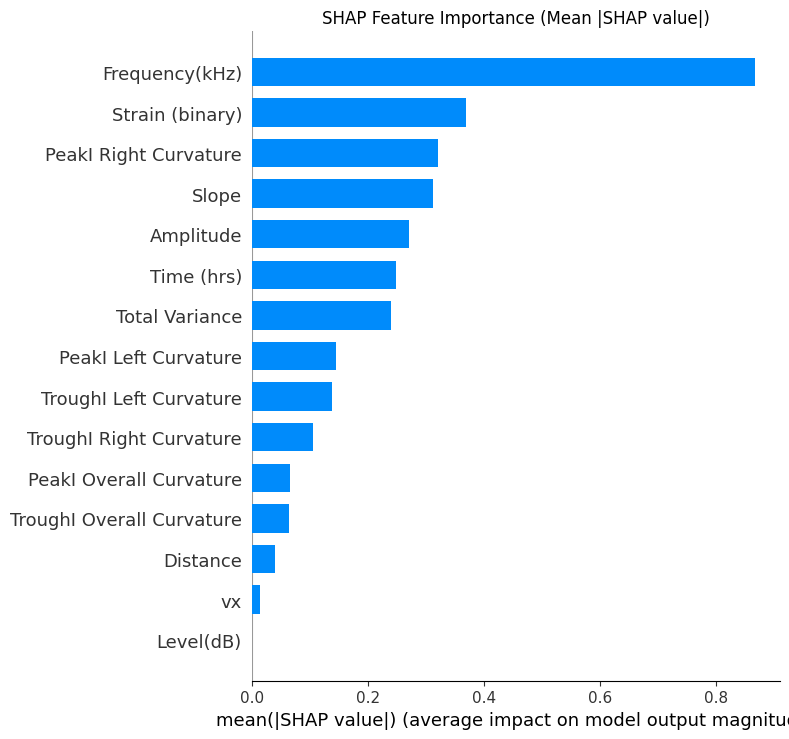

In [15]:
import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(best_rf_model.named_steps["rf"])

# Get preprocessed test data
X_test_preprocessed = best_rf_model.named_steps["preprocessor"].transform(X_test)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_preprocessed)

# Summary plot
plt.figure(figsize=(5, 4))
shap.summary_plot(
    shap_values, X_test_preprocessed, feature_names=feature_names, show=False
)
plt.title("SHAP Feature Importance")
print(plt.gca().get_yticklabels())
# plt.gca().set_yticklabels(feature_names, rotation=45)
plt.tight_layout()
plt.show()

# Bar plot of mean absolute SHAP values
plt.figure(figsize=(5, 4))
shap.summary_plot(
    shap_values,
    X_test_preprocessed,
    feature_names=feature_names,
    plot_type="bar",
    show=False,
)
plt.title("SHAP Feature Importance (Mean |SHAP value|)")
plt.tight_layout()
plt.show()

In [16]:
shap_interaction_values = explainer.shap_interaction_values(X_test_preprocessed)

In [17]:
def plot_shap_dependence(ft1, ft2):
    top_features = importance_df["Feature"].values
    feature_idx1 = list(feature_names).index(top_features[ft1])
    feature_idx2 = list(feature_names).index(top_features[ft2])

    # Main effects and interaction using shap.dependence_plot
    shap.dependence_plot(
        feature_idx1,
        shap_values,
        X_test_preprocessed,
        feature_names=feature_names,
        show=False,
    )
    plt.title(f"{top_features[ft1]} Main Effect")
    plt.figure(figsize=(3, 3))
    shap.dependence_plot(
        feature_idx2,
        shap_values,
        X_test_preprocessed,
        feature_names=feature_names,
        show=False,
    )
    plt.title(f"{top_features[ft2]} Main Effect")
    plt.figure(figsize=(3, 3))
    shap.dependence_plot(
        (feature_idx1, feature_idx2),
        shap_interaction_values,
        X_test_preprocessed,
        feature_names=feature_names,
        show=False,
        interaction_index=feature_idx2,
    )
    plt.title(f"{top_features[ft1]} x {top_features[ft2]} Interaction")

    plt.tight_layout()
    plt.show()

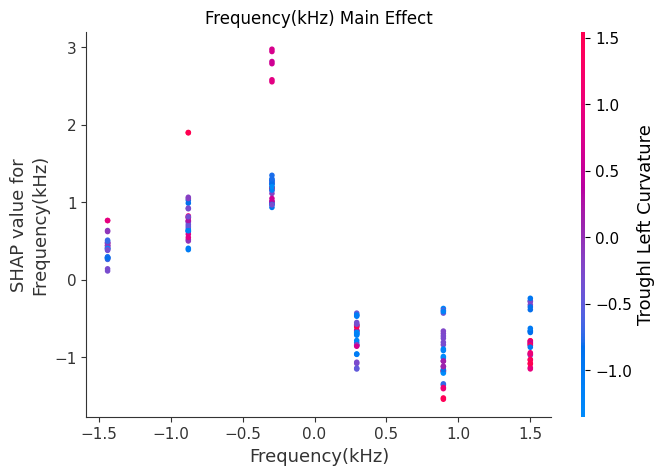

<Figure size 300x300 with 0 Axes>

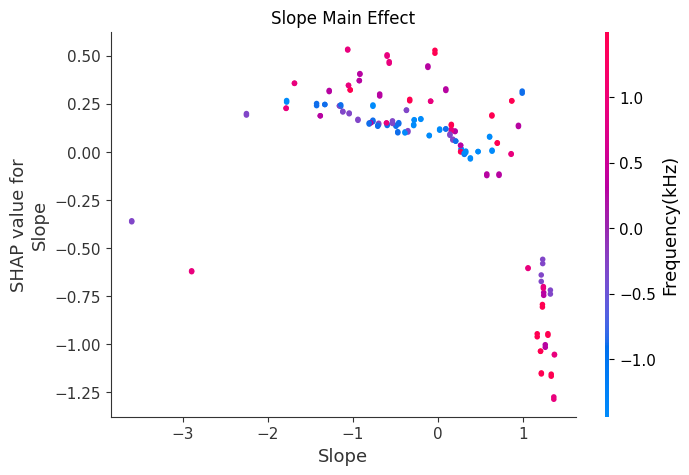

<Figure size 300x300 with 0 Axes>

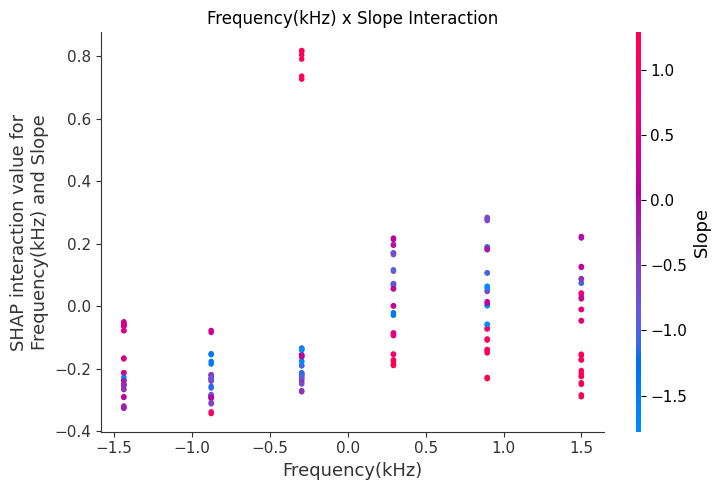

In [18]:
plot_shap_dependence(0, 1)

In [19]:
def plot_results(x, y, alpha=0.2, markersize=5, title="", color=None):
    if color is None:
        color = np.random.rand(
            3,
        )
        while np.mean(color) > 0.6:
            color = np.random.rand(
                3,
            )
    plt.plot(x, y, "o", alpha=alpha, markersize=markersize, color=color)
    plt.plot([5, 20], [5, 20], "k--", alpha=0.5)
    plt.axis("square")
    plt.xticks(np.arange(5, 21, 5))
    plt.yticks(np.arange(5, 21, 5))
    plt.xlim(5, 20)
    plt.ylim(5, 20)
    plt.title(title)
    plt.xlabel("GT # Synapses")
    plt.ylabel("Predicted # Synapses")

In [20]:
def train_plot_result(df, rf_pipeline):
    df = split_by_mouse(df)
    X_train, X_test, y_train, y_test, preprocessor = RF_data_prep(
        df, num_features, cat_features, log_features, minmax_features
    )
    dB_bins = [10, 20, 30, 40, 50, 60, 70, 80]
    plt.figure(figsize=(10, 4))

    color_palette = plt.cm.get_cmap("tab10", len(dB_bins) + 2)
    # iterate over dB levels:
    for dB in dB_bins:
        features = num_features + cat_features + log_features + minmax_features
        data = df[
            (df["Level(dB)"] >= dB) & (df["Level(dB)"] < dB + 10) & (df["Noise"] >= 0)
        ]
        X = data[features]
        y = data["SynapsesPerIHC"]
        X_train1, X_test1, y_train1, y_test1 = (
            X[data.DataGroup != "Test"],
            X[data.DataGroup == "Test"],
            y[data.DataGroup != "Test"],
            y[data.DataGroup == "Test"],
        )
        if len(X_train1) > 0 and len(X_test1) > 0:
            rf_pipeline.fit(X_train1, y_train1)
            r2 = rf_pipeline.score(X_test1, y_test1)
            rmse = np.sqrt(np.mean((y_test1 - rf_pipeline.predict(X_test1)) ** 2))
            print(
                f"{dB}-{dB + 5} dB, {len(data)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}"
            )
            plt.subplot(2, 5, dB // 10)
            plot_results(
                y_test1,
                rf_pipeline.predict(X_test1),
                title=f"{dB}-{dB + 5} dB",
                color=color_palette(dB // 10 - 1),
            )
            # show R2 in lower right corner of plot:
            plt.text(
                19.75,
                5,
                f"R2: {r2:.2f}",
                fontsize=10,
                horizontalalignment="right",
                verticalalignment="bottom",
            )

    # run on all data:
    rf_pipeline.fit(X_train, y_train)
    r2 = rf_pipeline.score(X_test, y_test)
    rmse = np.sqrt(np.mean((y_test - rf_pipeline.predict(X_test)) ** 2))
    print(f"All data, {len(df)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
    plt.subplot(2, 5, 9)
    plot_results(
        y_test,
        rf_pipeline.predict(X_test),
        alpha=0.05,
        title=f"All",
        color=color_palette(-2),
    )
    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    test_set = df[df["DataGroup"] == "Test"]
    test_set["RF predictions"] = rf_pipeline.predict(X_test)

    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    plt.tight_layout()
    plt.show()

10-15 dB, 542 samples, R2: -0.122, RMSE: 2.586
20-25 dB, 1014 samples, R2: 0.342, RMSE: 2.219
30-35 dB, 1176 samples, R2: 0.317, RMSE: 2.167
40-45 dB, 1121 samples, R2: 0.329, RMSE: 2.261
50-55 dB, 1046 samples, R2: 0.307, RMSE: 2.594
60-65 dB, 1054 samples, R2: 0.337, RMSE: 2.609
70-75 dB, 1074 samples, R2: 0.544, RMSE: 2.765
80-85 dB, 866 samples, R2: 0.407, RMSE: 2.821
All data, 7893 samples, R2: 0.421, RMSE: 2.418


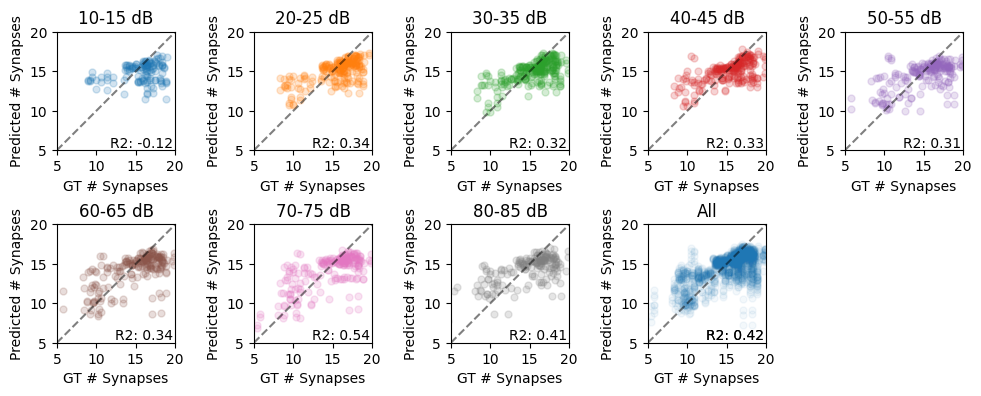

In [21]:
train_plot_result(final_clean_strained, best_rf_model)

Best RF score: 0.744, R2 on test set: 0.508
10-15 dB, 542 samples, R2: -0.116, RMSE: 2.579
20-25 dB, 1014 samples, R2: 0.350, RMSE: 2.206
30-35 dB, 1176 samples, R2: 0.305, RMSE: 2.186
40-45 dB, 1121 samples, R2: 0.336, RMSE: 2.249
50-55 dB, 1046 samples, R2: 0.316, RMSE: 2.578
60-65 dB, 1054 samples, R2: 0.332, RMSE: 2.619
70-75 dB, 1074 samples, R2: 0.535, RMSE: 2.794
80-85 dB, 866 samples, R2: 0.432, RMSE: 2.762
All data, 7893 samples, R2: 0.443, RMSE: 2.373


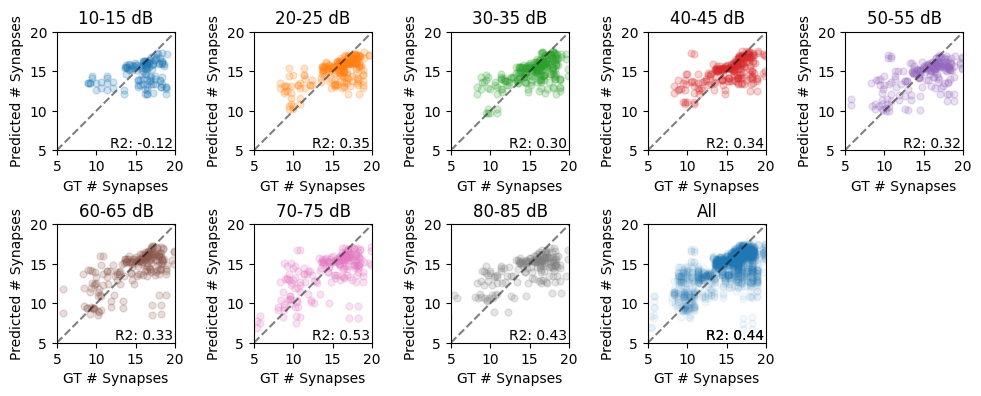

In [22]:
rf_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "rf",
            RandomForestRegressor(
                random_state=1,
                n_estimators=50,
                min_samples_split=30,
                min_samples_leaf=2,
                max_features=0.5,
                max_depth=30,
            ),
        ),
    ]
)
rf_pipeline.fit(X_train, y_train)
r2 = rf_pipeline.score(X_test, y_test)
print(
    f"Best RF score: {rf_pipeline.score(X_train, y_train):.3f}, R2 on test set: {r2:.3f}"
)
train_plot_result(final_clean_strained, rf_pipeline)

In [23]:
def train_plot_result_frequency(df, rf_pipeline):
    df = split_by_mouse(df)
    X_train, X_test, y_train, y_test, preprocessor = RF_data_prep(
        df, num_features, cat_features, log_features, minmax_features
    )
    freqs = sorted(X_train["Frequency(kHz)"].unique())
    plt.figure(figsize=(10, 4))

    color_palette = plt.cm.get_cmap("tab10", len(freqs) + 2)
    # iterate over dB levels:
    for i, frq in zip(range(len(freqs)), freqs):
        features = num_features + cat_features + log_features + minmax_features
        data = df[df["Frequency(kHz)"] == frq]
        X = data[features]
        y = data["SynapsesPerIHC"]
        X_train1, X_test1, y_train1, y_test1 = (
            X[data.DataGroup != "Test"],
            X[data.DataGroup == "Test"],
            y[data.DataGroup != "Test"],
            y[data.DataGroup == "Test"],
        )
        if len(X_train1) > 0 and len(X_test1) > 0:
            rf_pipeline.fit(X_train1, y_train1)
            r2 = rf_pipeline.score(X_test1, y_test1)
            rmse = np.sqrt(np.mean((y_test1 - rf_pipeline.predict(X_test1)) ** 2))
            print(f"{frq}Hz, {len(data)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
            plt.subplot(2, 4, i + 1)
            plot_results(
                y_test1,
                rf_pipeline.predict(X_test1),
                title=f"{frq}Hz",
                color=color_palette(i),
            )
            # show R2 in lower right corner of plot:
            plt.text(
                19.75,
                5,
                f"R2: {r2:.2f}",
                fontsize=10,
                horizontalalignment="right",
                verticalalignment="bottom",
            )

    # run on all data:
    rf_pipeline.fit(X_train, y_train)
    r2 = rf_pipeline.score(X_test, y_test)
    rmse = np.sqrt(np.mean((y_test - rf_pipeline.predict(X_test)) ** 2))
    print(f"All data, {len(df)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
    plt.subplot(2, 4, 7)
    plot_results(
        y_test,
        rf_pipeline.predict(X_test),
        alpha=0.05,
        title=f"All",
        color=color_palette(-2),
    )
    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    test_set = df[df["DataGroup"] == "Test"]
    test_set["RF predictions"] = rf_pipeline.predict(X_test)

    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    plt.tight_layout()
    plt.show()

8.0Hz, 1428 samples, R2: 0.561, RMSE: 1.068
11.3Hz, 1374 samples, R2: 0.152, RMSE: 1.040
16.0Hz, 1331 samples, R2: -0.433, RMSE: 1.553
22.6Hz, 1254 samples, R2: 0.237, RMSE: 3.428
32.0Hz, 1240 samples, R2: 0.307, RMSE: 3.279
45.2Hz, 1266 samples, R2: 0.447, RMSE: 2.893
All data, 7893 samples, R2: 0.421, RMSE: 2.418


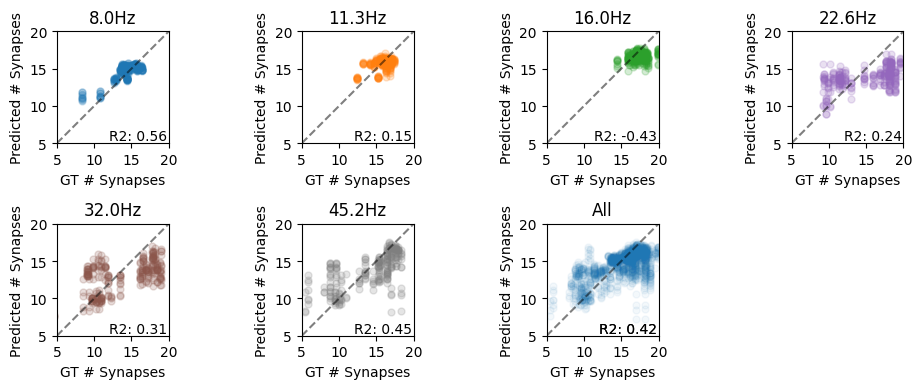

In [24]:
train_plot_result_frequency(final_clean_strained, best_rf_model)